<a href="https://colab.research.google.com/github/SumukhaSrivatsa-BSC/BSC_AI_Training/blob/main/06-07-2026/06_07_2026_Data_Extraction_Through_APIs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1 - run this first in Google Colab
! pip install requests pandas matplotlib --quiet

import requests
import pandas as pd
import matplotlib.pyplot as plt

print ("Setup complete")

Setup complete


In [ ]:
url = "https://api.github.com/users/octocat"
response = requests.get (url)

print ("Status Code:",response.status_code)

# convert response text -> Python dict
data = response.json ()

print (data ["login"], "-", data["public_repos"],
"public repos")
print (data ["followers"],
"followers")

Status Code: 200
octocat - 8 public repos
23188 followers


In [ ]:
# Cell 3 - extract a list of repositories
url = "https://api.github.com/users/octocat/repos"
response = requests.get(url, params={"per_page": 10})
repos = response.json()

# a LIST of dicts this

df = pd.DataFrame(repos)[["name", "language", "stargazers_count", "forks_count"]]

df = df.sort_values("stargazers_count", ascending=False)
df.head(10)

,name,language,stargazers_count,forks_count
6,Spoon-Knife,HTML,13877,157835
3,Hello-World,None,3660,6168
5,octocat.github.io,CSS,1125,553
2,hello-worId,None,764,289
4,linguist,Ruby,730,276
1,git-consortium,None,583,171
7,test-repo1,None,464,43
0,boysenberry-repo-1,None,455,26


In [ ]:
from google.colab import userdata
GITHUB_TOKEN = userdata.get ("GITHUB_TOKEN")

print ("Token loaded:", bool (GITHUB_TOKEN) )

Token loaded: True


In [ ]:
# Cell - compare limits with and without a token

# Anonymous request
resp_anon = requests.get("https://api.github.com/rate_limit")
print("Without token:", resp_anon.json()["rate"]["limit"], "req/hour")

# Authenticated request
headers = {
    "Authorization": f"Bearer {GITHUB_TOKEN}",
    "Accept": "application/vnd.github+json",
}
resp_auth = requests.get("https://api.github.com/rate_limit", headers=headers)
print("With token:", resp_auth.json()["rate"]["limit"], "req/hour")

Without token: 60 req/hour
With token: 5000 req/hour


In [ ]:
# Cell - pull 3 pages of a real organization's repos
all_repos = []

for page in range(1, 4):
    resp = requests.get(
        "https://api.github.com/orgs/google/repos",
        params={"per_page": 30, "page": page},
        headers=headers,
    )

    batch = resp.json()
    if not batch:
        # no more pages left
        break # Exit loop if no more data
    all_repos.extend(batch)

print(f"Extracted {len(all_repos)} repositories")
df = pd.DataFrame(all_repos)[["name", "stargazers_count", "language"]]

Extracted 90 repositories


In [ ]:
import time

def safe_get (url, headers=None, params=None, retries=3) :
  for attempt in range (retries) :
    try:
      r = requests.get (url, headers=headers,
                        params=params, timeout=10)
      r.raise_for_status ()
      return r.json ()
    except requests.exceptions.HTTPError as e:
      if e.response.status_code == 403:
        print ("Rate limit hit - waiting 60s ... ")
        time.sleep (60)
      else:
        print ("HTTP error:", e.response.status_code)
        break
    except requests.exceptions.RequestException as e:
      print ("Network error:", e)
      time.sleep(2 ** attempt)

# Using the safe wrapper
data = safe_get (
    "https://api.github.com/users/octocat",
    headers=headers,
)

if data:
  print (data ["login"], "OK")
else:
  print ("Extraction failed after retries")

octocat OK


In [ ]:
# Save locally inside the Colab session
df.to_csv("github_repos.csv", index=False)
df.to_excel("github_repos.xlsx", index=False)

# Download straight to your computer
from google.colab import files
files.download ("github_repos.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

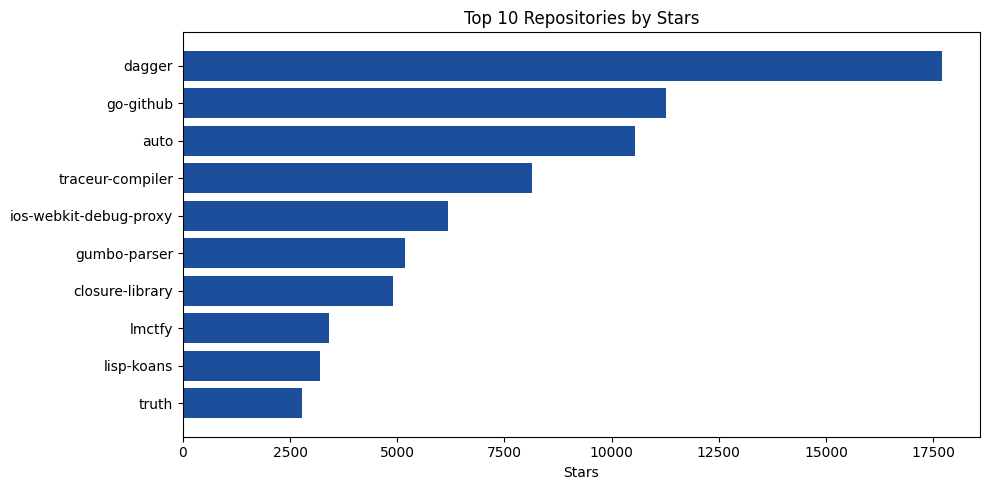

In [ ]:
top10 = df.sort_values(
    "stargazers_count", ascending=False
).head(10)

plt.figure (figsize=(10, 5))
plt.barh(top10["name"], top10["stargazers_count"],
color="#1B4F9C")
plt.xlabel ("Stars")
plt.title("Top 10 Repositories by Stars")
plt.gca().invert_yaxis ()
plt.tight_layout ()
plt.show()

 Data Extraction Through APIs

In [ ]:
!pip install requests pandas openpyxl

In [ ]:
import requests
import pandas as pd

# API Endpoint
url = "https://jsonplaceholder.typicode.com/users"

# Send GET request
response = requests.get(url)

# Check response status
if response.status_code == 200:
    print("Data fetched successfully!")

    # Convert JSON response to Python object
    data = response.json()

    # Convert JSON data into DataFrame
    df = pd.DataFrame(data)

    # Display first few rows
    print(df.head())

    # Save as CSV
    df.to_csv("users_data.csv", index=False)

    # Save as Excel
    df.to_excel("users_data.xlsx", index=False)

    print("Data saved to CSV and Excel files.")

else:
    print("Failed to retrieve data")
    print("Status Code:", response.status_code)

Data fetched successfully!
   id              name   username                      email  \
0   1     Leanne Graham       Bret          Sincere@april.biz   
1   2      Ervin Howell  Antonette          Shanna@melissa.tv   
2   3  Clementine Bauch   Samantha         Nathan@yesenia.net   
3   4  Patricia Lebsack   Karianne  Julianne.OConner@kory.org   
4   5  Chelsey Dietrich     Kamren   Lucio_Hettinger@annie.ca   

                                             address                  phone  \
0  {'street': 'Kulas Light', 'suite': 'Apt. 556',...  1-770-736-8031 x56442   
1  {'street': 'Victor Plains', 'suite': 'Suite 87...    010-692-6593 x09125   
2  {'street': 'Douglas Extension', 'suite': 'Suit...         1-463-123-4447   
3  {'street': 'Hoeger Mall', 'suite': 'Apt. 692',...      493-170-9623 x156   
4  {'street': 'Skiles Walks', 'suite': 'Suite 351...          (254)954-1289   

         website                                            company  
0  hildegard.org  {'name': 'Romaguera